In [1]:
import spacy
from nltk import tokenize
import pandas as pd
import pickle
from rapidfuzz import fuzz
import shutil
import seaborn as sns
import matplotlib.pyplot as plt
import textwrap
from geopy.geocoders import Nominatim
from time import sleep
import json

# 0) Import data

In [2]:
# Import metadata
df = pd.read_csv("../data/document_data_clean_filtered.csv")

In [25]:
#Create_backup:
shutil.copy("../data/document_data_clean_filtered.csv", "../data/document_data_clean_filtered_auto_backup.csv")
# Save df:
df.to_csv("../data/document_data_clean_filtered.csv", index=False)

# 0.5) Create contexts:

In [ ]:
for i, doc in df.iterrows():
    if doc["type_clean"] in ["presse généraliste", "presse officielle"]:

        with open(f"../data/corpus_txt/{doc["ark"]}.txt", "r", encoding='utf-8') as f:
            paragraphs = f.readlines()

        pertinent_context = []
        for j, paragraph in enumerate(paragraphs):
            if fuzz.ratio("eucalyptus", paragraph.lower()) > 75 or "eucalyp" in paragraph.lower() or "encalypt" in paragraph.lower() or "eucalipt" in paragraph.lower():
                pertinent_context.append(paragraph)

        pertinent_context = list(set(pertinent_context))                

        with open(f"../data/corpus_eucalyptus_only/{doc["ark"]}.txt", "w", encoding="utf-8") as f:
            f.write("\n".join(pertinent_context))
    
    else: 
        shutil.copy(f"../data/corpus_txt/{doc["ark"]}.txt", f"../data/corpus_eucalyptus_only/{doc["ark"]}.txt")

    if i % 100 == 0:
        print(f"{i} documents done")

0 documents done


MemoryError: 

# 1) Occurrences

In [3]:
def get_occurrences(ark, target="eucalyptus", ratio=75, path="../data/corpus_txt/"):
    with open(f"{path}{ark}.txt", "r", encoding='utf-8') as f:
        text = f.read().split()

    if type(target) is not list:
        occurrences = 0
        for word in text:
            if target == "eucalyptus":
                if fuzz.ratio("eucalyptus", word.lower()) > ratio or "eucalypt" in word.lower() or "encalypt" in word.lower() or "eucalipt" in word.lower():
                    occurrences += 1
            else:
                if fuzz.ratio(target, word.lower()) > ratio or target in word.lower():
                    occurrences += 1
        
        return occurrences

    else:
        occurrences_list = [0 for x in target]
        for word in text:
            for i, word_target in enumerate(target):
                if word_target == "eucalyptus":
                    if fuzz.ratio("eucalyptus", word.lower()) > ratio or "eucalypt" in word.lower() or "encalypt" in word.lower() or "eucalipt" in word.lower():
                        occurrences_list[i] += 1
                else:
                    if fuzz.ratio(word_target, word.lower()) > ratio or word_target in word.lower():
                        occurrences_list[i] += 1
    
        return occurrences_list

## 1.1) Occurrences Eucalyptus

In [ ]:
docs_occurrences = []
for doc in df["ark"].to_list():
    docs_occurrences.append(get_occurrences(doc))

df["occurences"] = docs_occurrences

In [ ]:
docs_eucalyptus_ratio = []
for i, ark in enumerate(df["ark"].to_list()):
    with open(f"../data/corpus_txt/{ark}.txt", "r", encoding='utf-8') as f:
        text = f.read().split()

    docs_eucalyptus_ratio.append(df.iloc[i]["occurences"] / len(text) * 100)

df["occurences_ratio"] = docs_eucalyptus_ratio

In [21]:
df["occurences_ratio"].describe()

count    17190.000000
mean         0.010299
std          0.038541
min          0.000026
25%          0.001671
50%          0.004397
75%          0.009936
max          2.762240
Name: occurences_ratio, dtype: float64

In [30]:
df.groupby(by="type_clean")["occurences_ratio"].describe()

,count,mean,std,min,25%,50%,75%,max
type_clean,,,,,,,,
annuaire,199.0,0.001365,0.002553,0.000047,0.000178,0.000527,0.001581,0.020210
monographie,4295.0,0.010796,0.067757,0.000026,0.001076,0.002388,0.006223,2.762240
presse généraliste,7997.0,0.010587,0.022651,0.000064,0.002964,0.005720,0.010731,0.522759
presse officielle,1352.0,0.010235,0.017622,0.000102,0.002293,0.004823,0.010887,0.223010
presse spécialisée,3347.0,0.009530,0.019529,0.000040,0.000995,0.003590,0.009982,0.448430


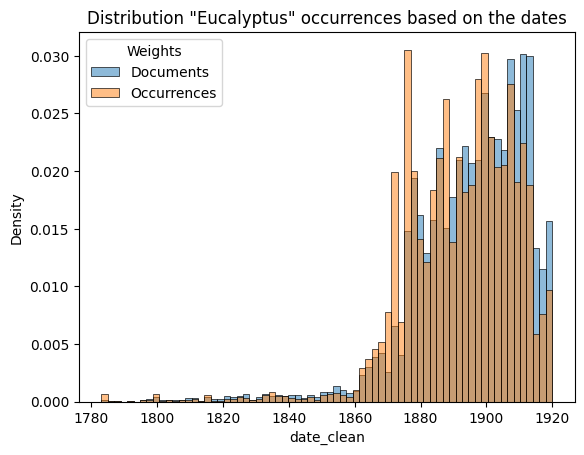

In [6]:
sns.histplot(df, x="date_clean", bins=70, stat="density", label='Documents', alpha=0.5)
sns.histplot(df, x="date_clean", weights="occurences", bins=70, stat="density", label='Occurrences', alpha=0.5)
plt.legend(title= "Weights", loc= "upper left")
plt.title('Distribution "Eucalyptus" occurrences based on the dates')
plt.show()

## 1.2) Specific types of Eucalyptus

In [4]:
#From Robin W. Doughty, "The Eucalyptus, A Natural and Commercial History of the Gum Tree", p.181-187
dict_occurrences_type = {
    "botryoides": [],
    "camaldulensis": [], 
    "citriodora": [],
    "deglupta": [],
    "globulus": [],
    "grandis": [],
    "obliqua": [],
    "regnans": [],
    "saligna": [],
    "tereticornis": [],
    "urophylla": [],
    "viminalis": []
}

In [ ]:
#TODO: modify "get_occurrences" in order to take a list of words and send a dict of the number of occurrences for each type
for j, doc in enumerate(df["ark"].to_list()):
    docs_occurrences = get_occurrences(doc, target=list(dict_occurrences_type.keys()), ratio=80)
    for i, key in enumerate(dict_occurrences_type.keys()):
        dict_occurrences_type[key].append(docs_occurrences[i])
     
    if j % 100 == 0:
        print(f"{j} documents processed")

for type in dict_occurrences_type.keys():
    df[f"occurences_{type}"] = dict_occurrences_type[type]

0 documents processed
100 documents processed
200 documents processed
300 documents processed
400 documents processed
500 documents processed
600 documents processed
700 documents processed
800 documents processed
900 documents processed
1000 documents processed
1100 documents processed
1200 documents processed
1300 documents processed
1400 documents processed
1500 documents processed


## 1.3) Specific place occurrences

In [14]:
#Palestine
palestine_occurrences = []
for doc in df["ark"].to_list():
    palestine_occurrences.append(get_occurrences(doc, target="palestine", ratio=85))

df["palestine"] = palestine_occurrences

In [12]:
df[df["type_clean"] != "annuaire"].sort_values(by="palestine", ascending=False)[["palestine", "occurences", "title_clean", "date_clean", "author_name_clean", "type_clean"]].head(15)

,palestine,occurences,title_clean,date_clean,author_name_clean,type_clean
13133,12,28,L'Écho sioniste,1900.0,NaN,presse généraliste
10305,9,5,Février-mai 1880. Herborisations au Levant,1882.0,"Barbey, William",monographie
953,4,2,"Dictionnaire géographique, administratif, post...",1869.0,"Joanne, Adolphe",monographie
12967,4,1,Revue de théologie et des questions religieuses,1900.0,NaN,presse généraliste
15601,4,2,Guide Rosenwald,1913.0,NaN,presse généraliste
12901,3,1,L'Écho sioniste,1899.0,NaN,presse généraliste
16192,3,1,L'Univers israélite,1915.0,NaN,presse généraliste
16316,3,1,Guide Rosenwald,1917.0,NaN,presse généraliste
6786,2,1,Bulletin trimestriel,1908.0,"Société d'agriculture, d'horticulture et d'acc...",presse spécialisée
47,2,8,Revue trimestrielle de la Société d'archéologi...,1884.0,"Société d'archéologie, de littérature, science...",presse spécialisée


# 1.3) Places - Spacy and Nominatim

In [73]:
# Load the pre-trained model
nlp = spacy.load("fr_core_news_lg")

# Load nominatim
loc = Nominatim(user_agent="Eucalyptus_test")

In [85]:
# Loop through docs
places = []
countries = []
ark_list = df[df["publisher_place_clean"] == "Paris"]["ark"].to_list()
nominatim_queries = {}


for i, ark in enumerate(ark_list):
    with open(f"../data/corpus_eucalyptus_only/{ark}.txt", "r", encoding='utf-8') as f:
        text = f.read()

    list_of_texts = textwrap.wrap(text, 100000)

    countries_in_doc = []
    places_in_doc = []

    for text in list_of_texts:
        nlp_doc = nlp(text)
        spacy_locs = [str(ent) for ent in nlp_doc.ents if ent.label_ == "LOC"]
        for word in spacy_locs:
            # Check if query has already been made
            if word in nominatim_queries.keys():
                if nominatim_queries[word] != "Error":
                    countries_in_doc.append(nominatim_queries[word].split(", ")[-1])
                    places_in_doc.append((word, str(nominatim_queries[word].split(", ")[0])))
            else:
                #If it hasn't been made, search nominatim
                sleep(1)
                location = loc.geocode(word, language="fr")
                if location:
                    countries_in_doc.append(str(location[0].split(", ")[-1]))
                    places_in_doc.append((word, str(location[0].split(", ")[0])))
                    nominatim_queries[word] = str(location[0])
                else: 
                    nominatim_queries[word] = "Error"
                with open("nominatim_queries.json", "w", encoding="utf-8") as f:
                    json.dump(nominatim_queries, f, ensure_ascii=False)

    places.append(places_in_doc)
    countries.append(countries_in_doc)

    if i % 100 == 0:
        print(f"{i} documents done")
        #Save places and countries
        with open("places_countries.pkl", "wb") as fp:
            pickle.dump((places, countries), fp)



KeyboardInterrupt: 

In [ ]:
# Save df:
df.to_csv("../data/document_data_clean_filtered_test_with_occurrences_places.csv", index=False)

# 2) Apply spacy to all texts

In [21]:
docs_ner = []

for ark in df["ark"].to_list():
    with open(f"../data/corpus_txt/{ark}.txt", "r", encoding='utf-8') as f:
            text = f.read()
    docs_ner.append(nlp(text))

#Save docs_ner
with open("docs_ner.pkl", "wb") as fp:
    pickle.dump(docs_ner, fp)

ValueError: [E088] Text of length 3676236 exceeds maximum of 1000000. The parser and NER models require roughly 1GB of temporary memory per 100,000 characters in the input. This means long texts may cause memory allocation errors. If you're not using the parser or NER, it's probably safe to increase the `nlp.max_length` limit. The limit is in number of characters, so you can check whether your inputs are too long by checking `len(text)`.